# **Aerofit Business Case**

**Importing libraries for data analysis**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# **Defining Problem Statement and Analysing basic metrics**

**Import the dataset and do usual data analysis steps like checking the structure & characteristics of the dataset**


In [109]:
df = pd.read_csv('aerofit_treadmill.csv')
df


,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47
...,...,...,...,...,...,...,...,...,...
175,KP781,40,Male,21,Single,6,5,83416,200
176,KP781,42,Male,18,Single,5,4,89641,200
177,KP781,45,Male,16,Single,5,5,90886,160
178,KP781,47,Male,18,Partnered,4,5,104581,120


In [110]:
df.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


In [7]:
df.ndim


2

In [8]:
df.shape


(180, 9)

# **Missing value and Outlier Detection**

# **Missing Values**

In [111]:
df.isnull().sum()

,0
Product,0
Age,0
Gender,0
Education,0
MaritalStatus,0
Usage,0
Fitness,0
Income,0
Miles,0


**Insights:**

Since there are no missing values in the dataset, we don't need to perform any imputation or removal techniques.
This is a positive aspect as it indicates cleaner data, ready for further analysis.


# **Outlier Detection:**

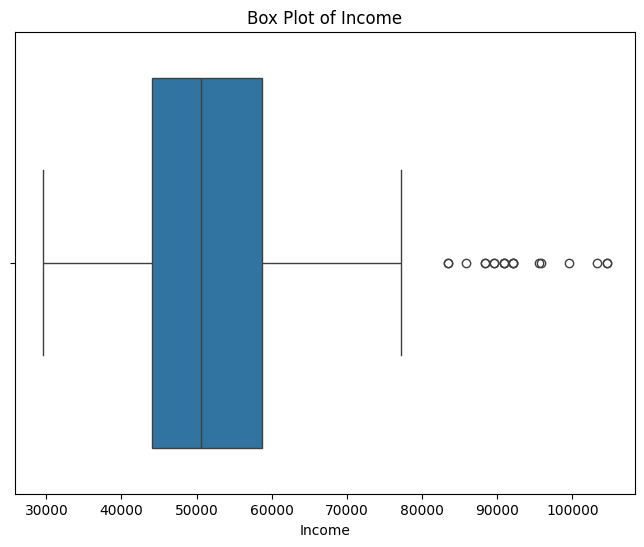

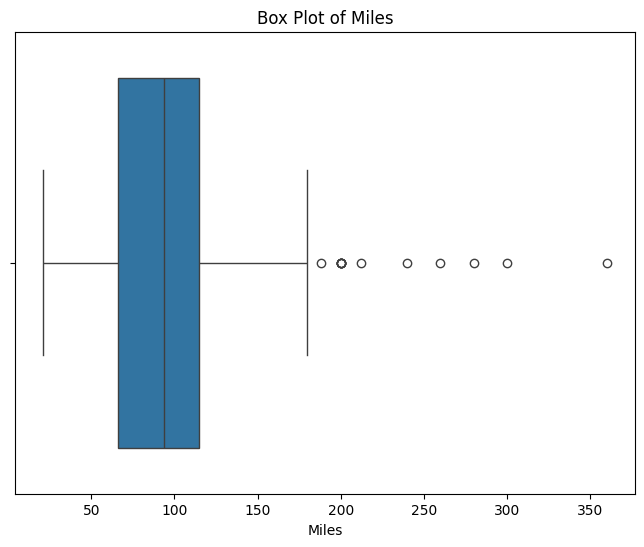

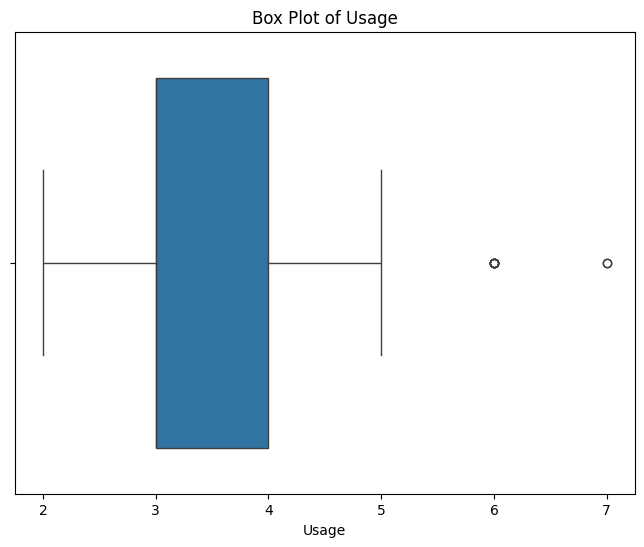

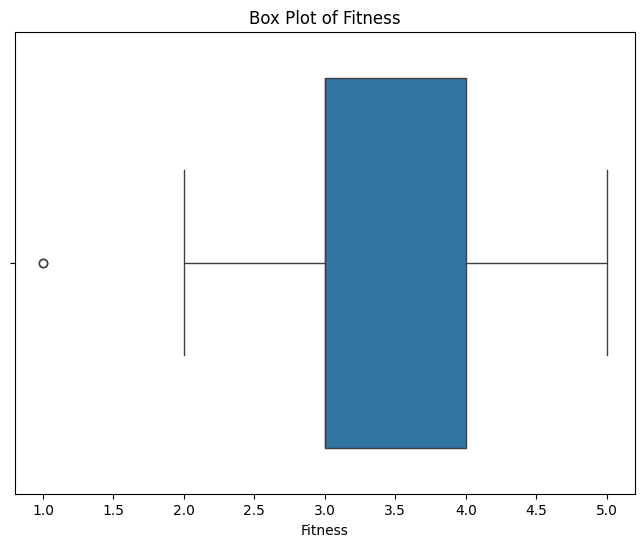

In [112]:
for column in ['Income', 'Miles', 'Usage', 'Fitness']:
  plt.figure(figsize=(8, 6))
  sns.boxplot(x=df[column])
  plt.title(f'Box Plot of {column}')
  plt.show()

# **Insights:**

**Income:**

There are a few potential outliers on the higher end of the income distribution.

This might indicate a small number of customers with significantly higher incomes compared to the majority.

**Miles:**

There are some potential outliers on both the lower and higher ends of the miles distribution.

This could indicate some customers who use the treadmill very little or very frequently compared to the average customer.

**Usage:**

There are some potential outliers on the higher end of the usage distribution.

This might represent customers who use the treadmill more frequently than the average customer.

**Fitness:**

There are a few potential outliers on the higher end of the fitness level distribution.

This might indicate some customers with exceptionally high fitness levels compared to the average customer.

# **Non-Graphical Analysis: Value counts and unique attributes**

In [16]:
df['Usage'] = df['Usage'].astype('str')
df['Fitness'] = df['Fitness'].astype('str')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    object
 6   Fitness        180 non-null    object
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(4), object(5)
memory usage: 12.8+ KB


**Insights:**

From the above analysis, it is clear that, data has total of 9 features with mixed alpha numeric data.
Also we can see that there is no missing data in the columns. The data type of all the columns are matching with the data present in them. But we will change the datatype of Usage and Fitness into str(object).

**Detect Outliers (using boxplot, “describe” method by checking the difference between mean and median)**

In [10]:
df.describe()

,Age,Education,Usage,Fitness,Income,Miles
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,28.788889,15.572222,3.455556,3.311111,53719.577778,103.194444
std,6.943498,1.617055,1.084797,0.958869,16506.684226,51.863605
min,18.000000,12.000000,2.000000,1.000000,29562.000000,21.000000
25%,24.000000,14.000000,3.000000,3.000000,44058.750000,66.000000
50%,26.000000,16.000000,3.000000,3.000000,50596.500000,94.000000
75%,33.000000,16.000000,4.000000,4.000000,58668.000000,114.750000
max,50.000000,21.000000,7.000000,5.000000,104581.000000,360.000000


**Insights:**

1. **Age** - The age range of customers spans from 18 to 50 year , with an average age of 29 years .
2. **Education** - Customer education levels vary between 12 and 21 years , with an average education duration of 16 years .
3. **Usage** - Customers intend to utilize the product anywhere from 2 to 7 times per week , with an average usage frequency of 3 times per week .
4. **Fitness** - On average, customers have rated their fitness at 3 on a 5-point scale, reflecting a moderate level of fitness .
5. **Income** - The annual income of customers falls within the range of USD 30,000 to USD 100,000 , with an average income of approximately USD 54,000 .
6. **Miles** - Customers' weekly running goals range from 21 to 360 miles , with an average target of 103 miles per week .

#### Age Column

- Categorizing the values in age column in 4 different buckets:

1. Young Adult: from 18 - 25
2. Adults: from 26 - 35
3. Middle Aged Adults: 36-45
4. Elder :46 and above

#### Education Column

- Categorizing the values in education column in 3 different buckets:

1. Primary Education: upto 12
2. Secondary Education: 13 to 15
3. Higher Education: 16 and above

#### Income Column

- Categorizing the values in Income column in 4 different buckets:

1. Low Income - Upto 40,000
2. Moderate Income - 40,000 to 60,000
3. High Income - 60,000 to 80,000
4. Very High Income - Above 80,000

#### Miles column

- Categorizing the values in miles column in 4 different buckets:

1. Light Activity - Upto 50 miles
2. Moderate Activity - 51 to 100 miles
3. Active Lifestyle - 101 to 200 miles
4. Fitness Enthusiast - Above 200 miles

In [92]:
#binning the age values into categories
bin_range1 = [17,25,35,45,float('inf')]
bin_labels1 = ['Young Adults', 'Adults', 'Middle Aged Adults', 'Elder']

df['age_group'] = pd.cut(df['Age'],bins = bin_range1,labels = bin_labels1)

#binning the education values into categories
bin_range2 = [0,12,15,float('inf')]
bin_labels2 = ['Primary Education', 'Secondary Education', 'Higher Education']

df['edu_group'] = pd.cut(df['Education'],bins = bin_range2,labels = bin_labels2)

#binning the income values into categories
bin_range3 = [0,40000,60000,80000,float('inf')]
bin_labels3 = ['Low Income','Moderate Income','High Income','Very High Income']

df['income_group'] = pd.cut(df['Income'],bins = bin_range3,labels = bin_labels3)

#binning the miles values into categories
bin_range4 = [0,50,100,200,float('inf')]
bin_labels4 = ['Light Activity', 'Moderate Activity', 'Active Lifestyle', 'Fitness Enthusiast ']

df['miles_group'] = pd.cut(df['Miles'],bins = bin_range4,labels = bin_labels4)

# **Univariate Analysis**

# **For continuous variable(s): Distplot, countplot, histogram for univariate analysis**

**Check if features like marital status, age have any effect on the product purchased (using countplot, histplots, boxplots etc)**

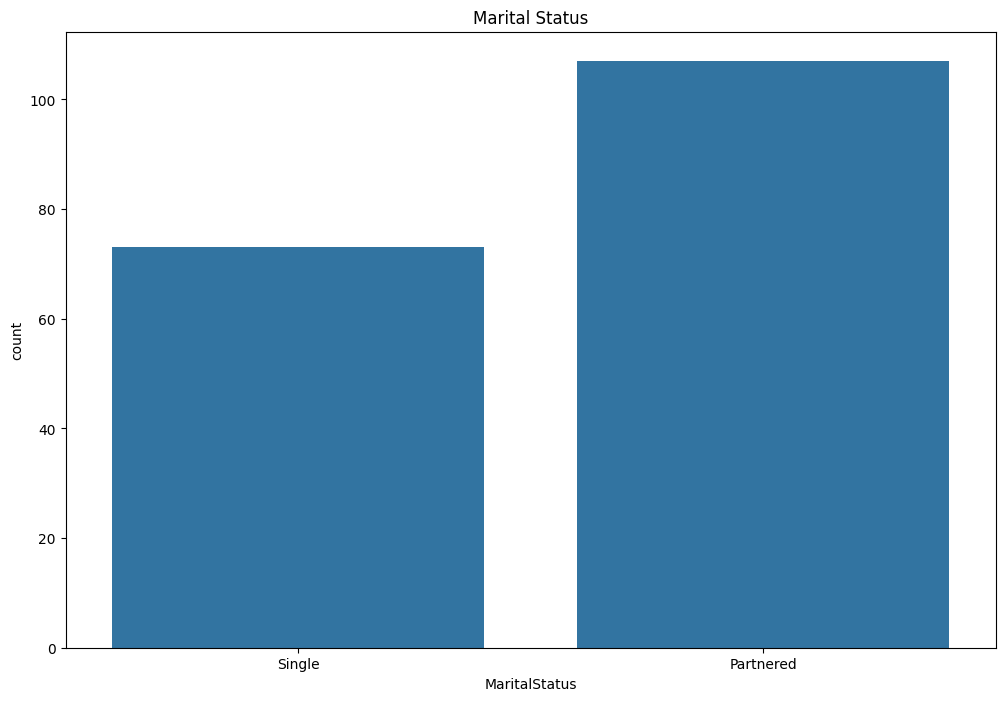

In [93]:
plt.figure(figsize=(12,8))
sns.countplot(data=df,x='MaritalStatus')
plt.title('Marital Status')
plt.show()

**Insights:**

It appears that a larger proportion of customers are married compared to single customers.
This suggests that married individuals might be more likely to purchase the treadmill than single individuals.



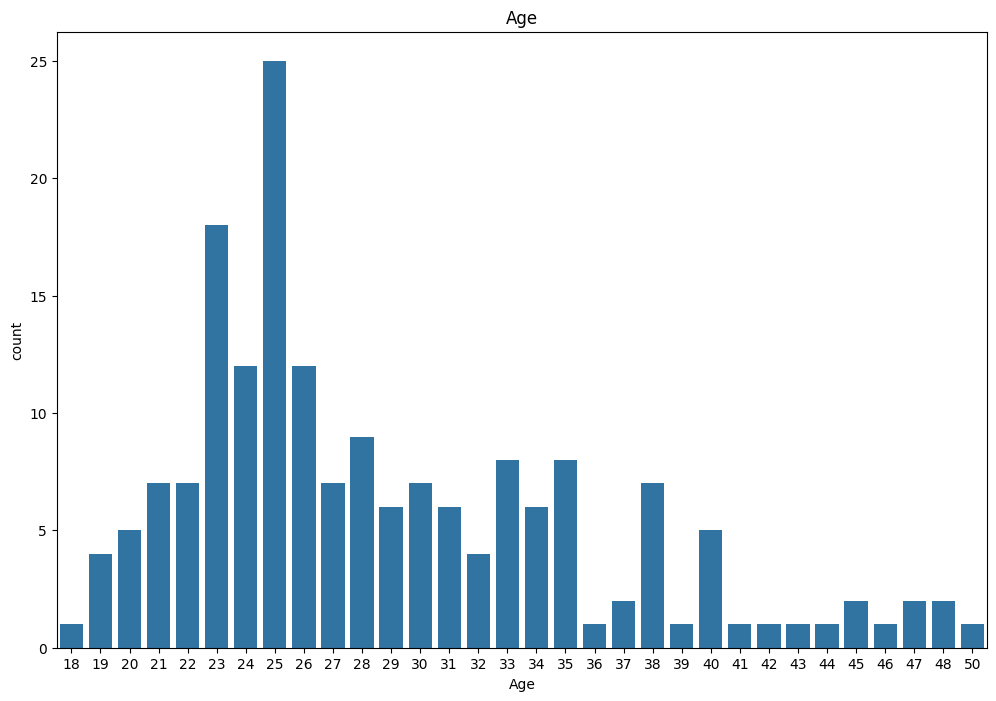

In [21]:
plt.figure(figsize=(12,8))
sns.countplot(data=df,x='Age')
plt.title('Age')
plt.show()

**Insights:**

We can see that the majority of customers are between 25 and 35 years old.    
There are fewer customers in the younger age group (below 25) and the older age group (above 40).        
This could imply that the target market for treadmills might be individuals in the 25-35 age rang

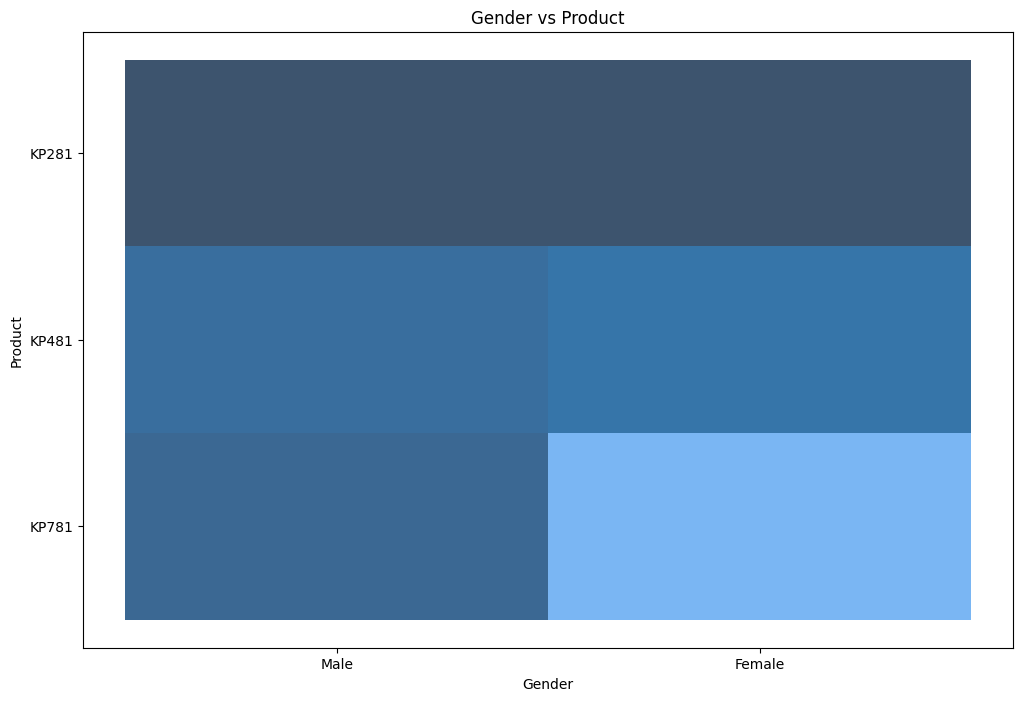

In [94]:
plt.figure(figsize=(12,8))
sns.histplot(data=df,x='Gender',y='Product')
plt.title('Gender vs Product')
plt.show()

**Insights:**

The histogram seems to be displaying the count of products purchased by each gender.
It's difficult to get precise insights without more information on how the histogram is plotted. However, we can make some general observations

Product Popularity by Gender:

We can potentially infer which product is most popular among men and women by looking at the bar heights for each product.

For example, if the KP281 bar is higher for females, it could mean that women tend to purchase KP281 more often than men.

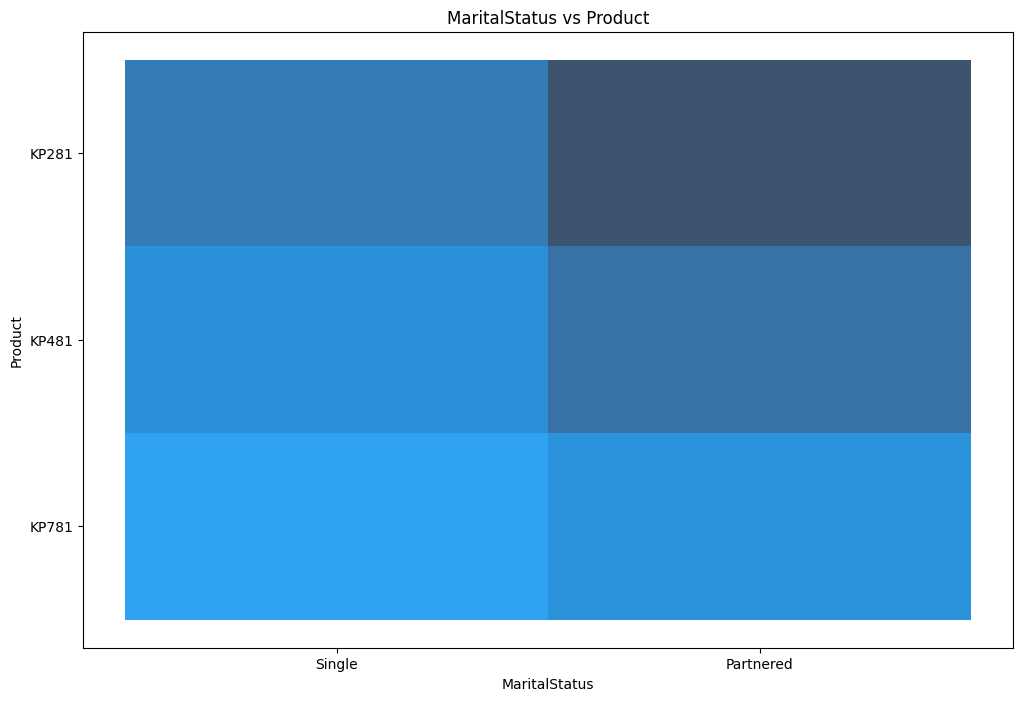

In [30]:
plt.figure(figsize=(12,8))
sns.histplot(data=df,x='MaritalStatus',y='Product')
plt.title('MaritalStatus vs Product')
plt.show()

**Insights:**

Product Popularity by Marital Status:

We can potentially infer which product is most popular among Single and Partnered by looking at the bar heights for each product.

For example, if the KP281 bar is higher for Partnered, it could mean that Partnered tend to purchase KP281 more often than single.

# **Box Plot**

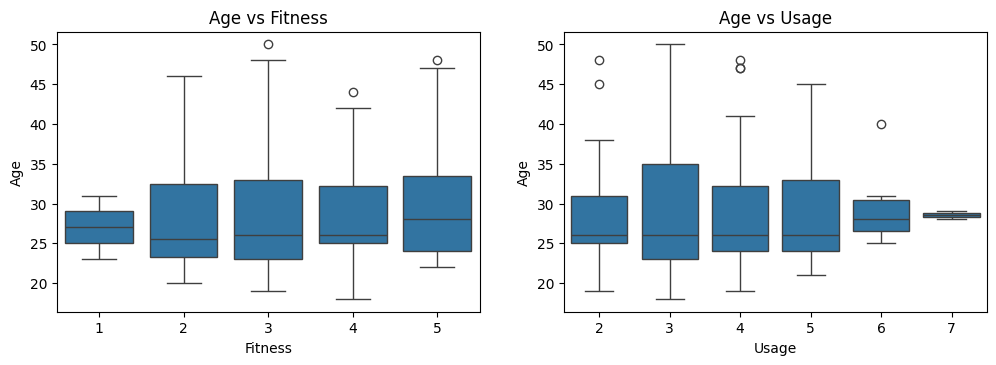

In [13]:
plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
sns.boxplot(data=df,y='Age',x='Fitness')
plt.title('Age vs Fitness')
plt.subplot(2,2,2)
sns.boxplot(data=df,y='Age',x='Usage')
plt.title('Age vs Usage')
plt.show()

**What can we infer from this plot?**

Age vs Fitness:
There seems to be a slight tendency for older individuals (above 40) to have a lower fitness level, although the spread across fitness levels is quite similar.
It appears that regardless of the fitness level (low, medium, high), the age distributions overlap considerably. No significant outliers concerning age and fitness level are detected

Age vs Usage:There's a general inclination towards lower usage among individuals in the older age group, and higher usage in the middle age group, even though the overall spread of age across different usage levels is relatively consistent. No prominent outliers are identified with respect to age and usage.

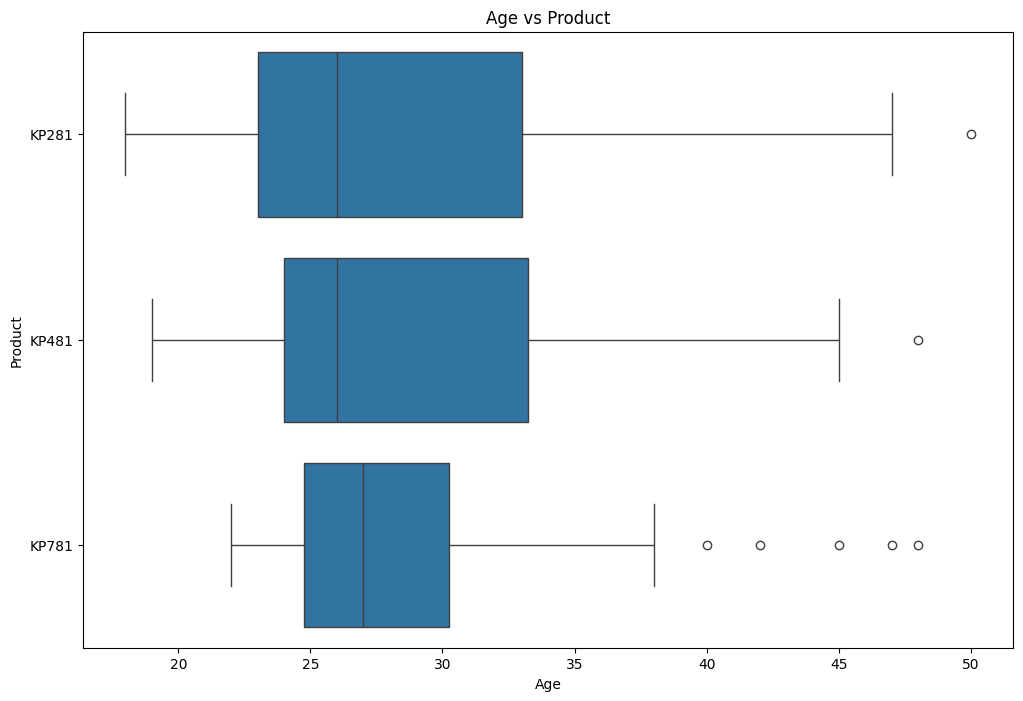

In [95]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df,x='Age',y='Product')
plt.title('Age vs Product')
plt.show()

**Insights:**

Boxplot representing the Age vs product purchased plot we can observe for products KP281,KP481 has similar median age is around 25 has less no.of outliers
whereas in KP781 product has median of 27 and also  we can observe there are outliers with this we can undestand this product mostly preferred by aged peoples

# **For correlation: Heatmaps, Pairplots**

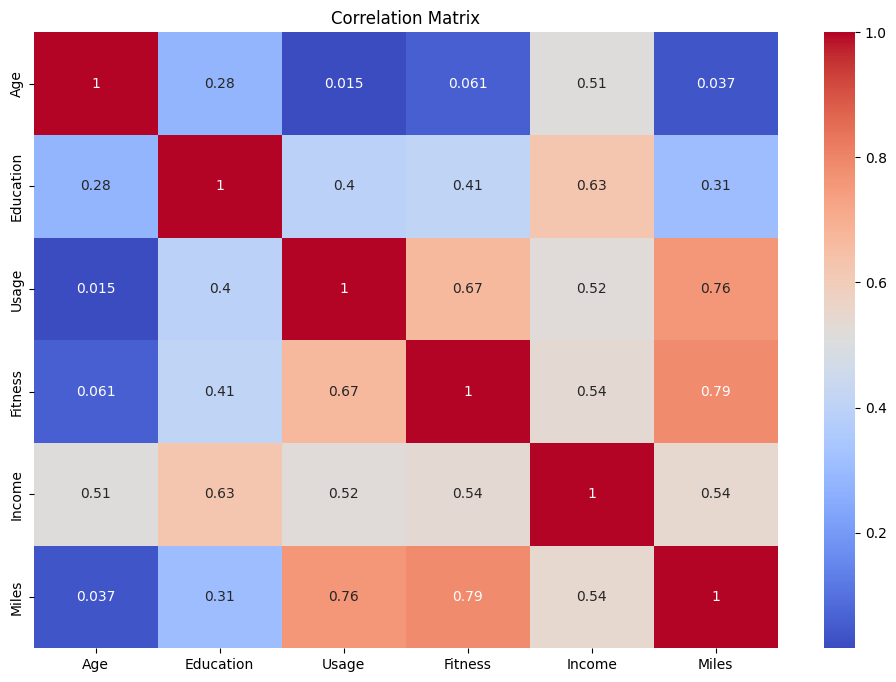

In [96]:

plt.figure(figsize=(12, 8))
correlation_matrix = df.select_dtypes(include=np.number).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


**Miles:** There is a moderate positive correlation between the number of miles a customer aims to run weekly and the type of treadmill they purchase.

**Income:** A moderate positive correlation is observed between income and Product_code. This aligns with the idea that customers with higher incomes may tend to buy more advanced and expensive treadmills.

**Income and Miles**: There is also a moderate positive correlation between income and the target number of weekly miles. This implies customers with higher incomes might be more inclined to run longer distances or have a higher usage intensity.

**Usage and Miles:** A strong positive correlation exists between the frequency of treadmill usage and the number of miles customers want to run weekly. This is logical, as higher usage will likely result in a greater number of miles covered.

**Fitness and Miles:** Fitness level and target miles show a moderate positive correlation. Individuals who consider themselves fitter might aim to run longer distances.


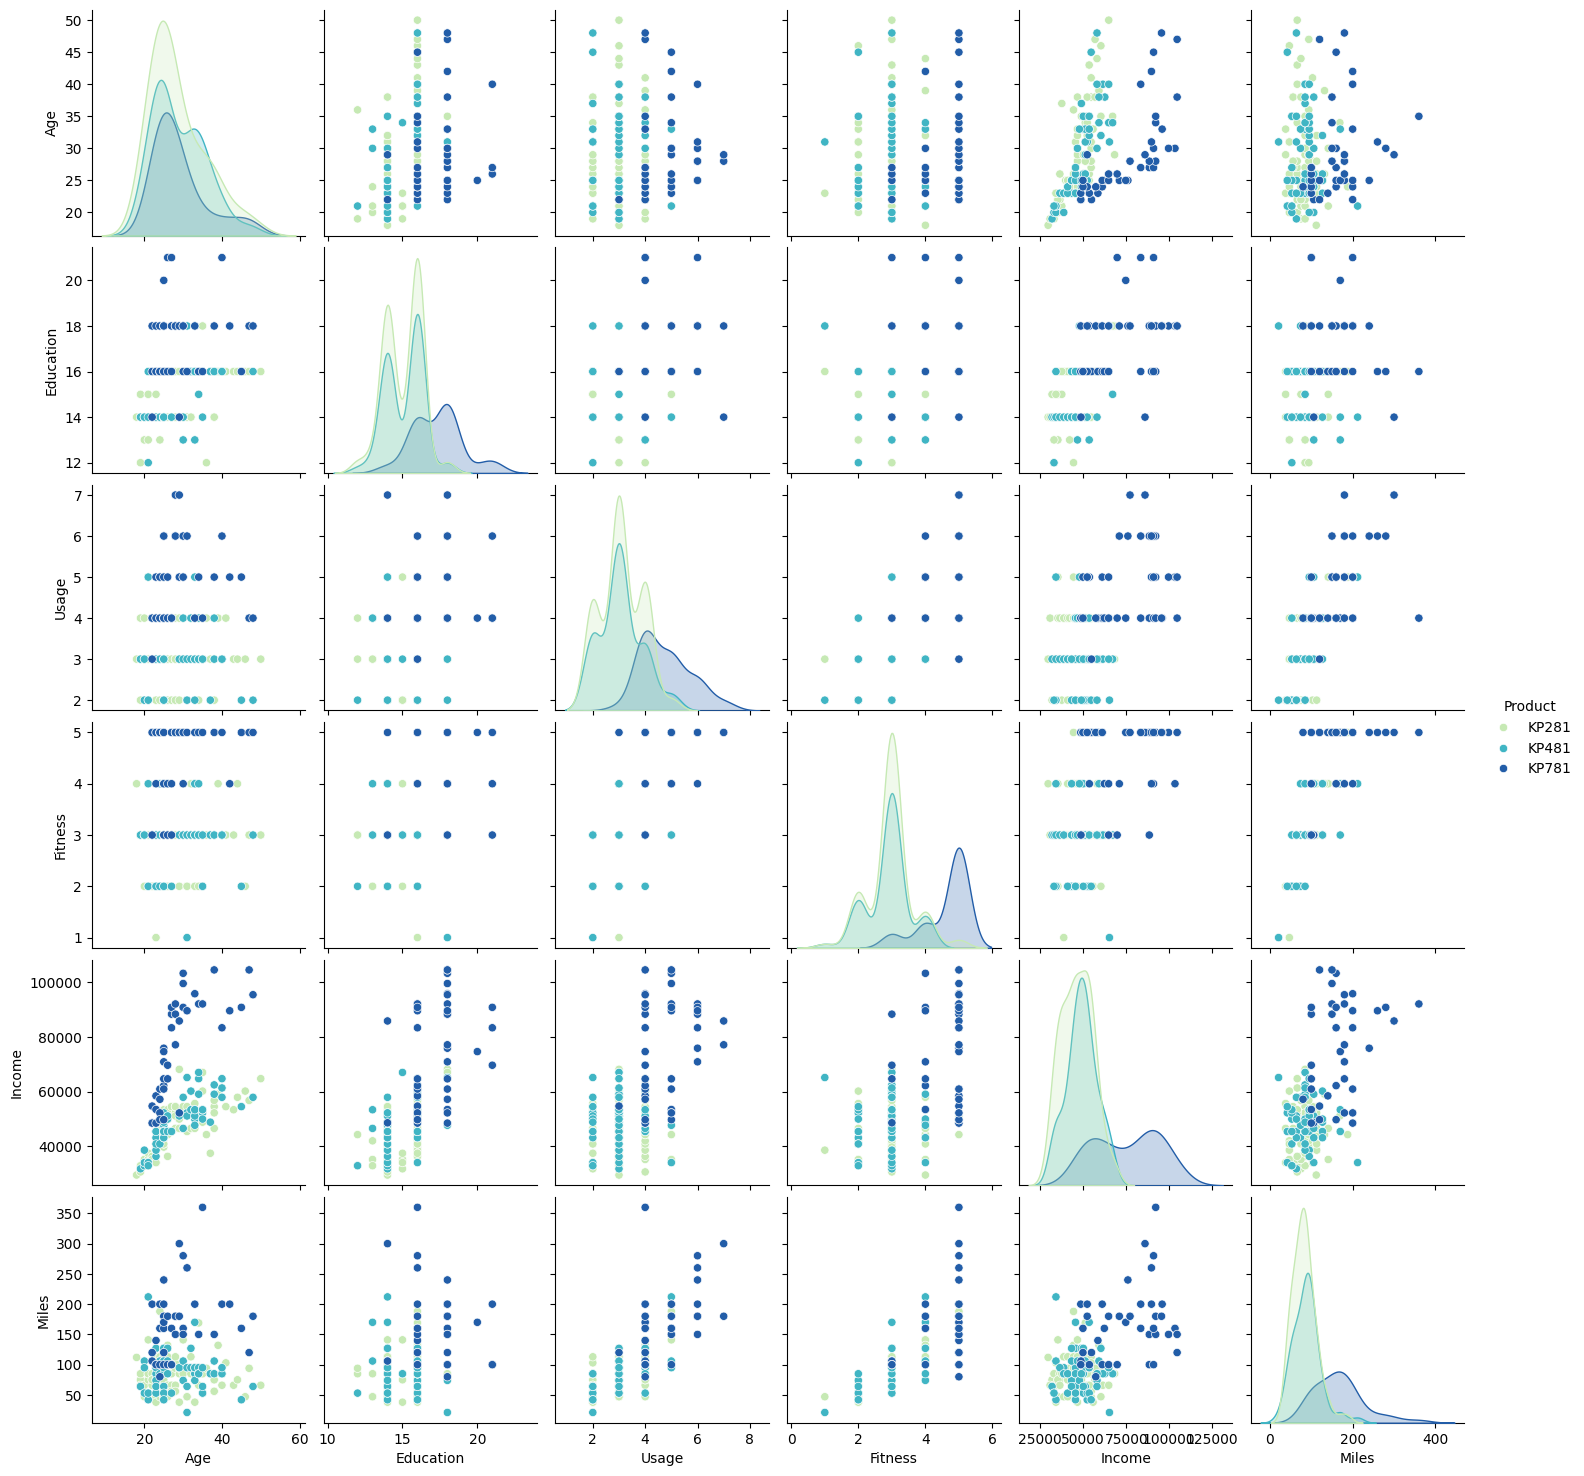

In [97]:
sns.pairplot(df,hue='Product',palette='YlGnBu')
plt.show()

Strong positive correlation between 'Usage' and 'Miles' As Usage increases, Miles tends to increase.
Moderate positive correlation between 'Income' and 'Miles' Higher income customers tend to run more miles.
Moderate positive correlation between 'Product' and 'Miles' Customers buying more advanced treadmills (higher Product code) tend to run more miles.
Moderate positive correlation between 'Product' and 'Income'  Higher income customers tend to buy more advanced treadmills.

Potential Outliers:

We can identify potential outliers in the scatter plots, particularly for 'Miles' and 'Income', as there might be some extreme values.

Product vs. Other Variables:

We can see the relationship between the type of treadmill (Product) and other variables like 'Miles', 'Income', 'Age', etc.

For example, customers with higher incomes and those who aim to run more miles may tend to purchase higher-end treadmill models.

**Representing the marginal probability like - what percent of customers have purchased KP281, KP481, or KP781 in a table**

In [46]:
pd.crosstab(df['Product'],df['Gender'],margins=True)

Gender,Female,Male,All
Product,,,
KP281,40,40,80
KP481,29,31,60
KP781,7,33,40
All,76,104,180


**Insights:**

We can observe that Product purchased count of Female and male distribution
we can get from above crosstab function that most popular or most purchased product is KP281 by both male and females
Least purchases has done for the product KP781 By Females, and by Male the least purchase product is KP481


In [99]:
percent_customers=pd.crosstab(df['Product'], columns='count', normalize=True) * 100
round(percent_customers,2).reset_index()


col_0,Product,count
0,KP281,44.44
1,KP481,33.33
2,KP781,22.22


**Insights:**

Product Purchase Percentage:
Approximately 44.44% of customers purchased KP281,
Roughly 33.33% of customers opted for KP481 and
Around 22.23% of customers chose KP781.

# **Computing Probability - Marginal, Conditional Probability**

**Probability of product purchase w.r.t. gender**

In [100]:
pd.crosstab(index =df['Product'],columns = df['Gender'],margins = True,normalize = True ).round(2)

Gender,Female,Male,All
Product,,,
KP281,0.22,0.22,0.44
KP481,0.16,0.17,0.33
KP781,0.04,0.18,0.22
All,0.42,0.58,1.00


**Insights**:
1. The Probability of a treadmill being purchased by a female is 42% .
The conditional probability of purchasing the treadmill model given that the customer is female is
For Treadmill model KP281 - 22%
For Treadmill model KP481 - 16%
For Treadmill model KP781 - 4%
1. The Probability of a treadmill being purchased by a male is 58% .
The conditional probability of purchasing the treadmill model given that the customer is male is -
For Treadmill model KP281 - 22%
For Treadmill model KP481 - 17%
For Treadmill model KP781 - 18%

**Probability of product purchase w.r.t. Age**

In [101]:
pd.crosstab(index =df['Product'],columns = df['age_group'],margins = True,normalize = True ).round(2)

age_group,Young Adults,Adults,Middle Aged Adults,Elder,All
Product,,,,,
KP281,0.19,0.18,0.06,0.02,0.44
KP481,0.16,0.13,0.04,0.01,0.33
KP781,0.09,0.09,0.02,0.01,0.22
All,0.44,0.41,0.12,0.03,1.00


**Insights:**

1. The **`Probability`** of a treadmill being purchased by a **`Young Adult(18-25) is 44%`**.

    - **`The conditional probability`** of purchasing the treadmill model given that the customer is **`Young Adult`** is
    
        - For Treadmill model KP281 - **19%**
    
        - For Treadmill model KP481 - **16%**
    
        - For Treadmill model KP781 - **9%**


2. The **`Probability`** of a treadmill being purchased by a **`Adult(26-35) is 41%`**.

    - **`The conditional probability`** of purchasing the treadmill model given that the customer is **`Adult`** is -

        - For Treadmill model KP281 - **18%**
    
        - For Treadmill model KP481 - **13%**
    
        - For Treadmill model KP781 - **9%**
        
        
3. The **`Probability`** of a treadmill being purchased by a **`Middle Aged(36-45) is 12%`**.
        
        
4. The **`Probability`** of a treadmill being purchased by a **`Elder(Above 45) is only 3%`**.

**Probability of product purchase w.r.t. Education level**

In [102]:
pd.crosstab(index =df['Product'],columns = df['edu_group'],margins = True,normalize = True ).round(2)

edu_group,Primary Education,Secondary Education,Higher Education,All
Product,,,,
KP281,0.01,0.21,0.23,0.44
KP481,0.01,0.14,0.18,0.33
KP781,0.00,0.01,0.21,0.22
All,0.02,0.36,0.62,1.00


**Insights:**
1. The Probability of a treadmill being purchased by a customer with Higher Education(Above 15 Years) is 62% .
The conditional probability of purchasing the treadmill model given that the customer has Higher Education is
For Treadmill model KP281 - 23%
For Treadmill model KP481 - 18%
For Treadmill model KP781 - 21%
1. The Probability of a treadmill being purchased by a customer with Secondary Education(13-15 yrs) is 36% .
The conditional probability of purchasing the treadmill model given that the customer has Secondary Education is -
For Treadmill model KP281 - 21%
For Treadmill model KP481 - 14%
For Treadmill model KP781 - 1%
1. The Probability of a treadmill being purchased by a customer with Primary Education(0 to 12 yrs) is only 2% .

**Probability of product purchase w.r.t. Income**

In [103]:
pd.crosstab(index =df['Product'],columns = df['income_group'],margins = True,normalize = True ).round(2)

income_group,Low Income,Moderate Income,High Income,Very High Income,All
Product,,,,,
KP281,0.13,0.28,0.03,0.00,0.44
KP481,0.05,0.24,0.04,0.00,0.33
KP781,0.00,0.06,0.06,0.11,0.22
All,0.18,0.59,0.13,0.11,1.00


**Insights**:

1. The **`Probability`** of a treadmill being purchased by a customer with **`Low Income(<40k) is 18%`**.

    - **`The conditional probability`** of purchasing the treadmill model given that the customer has **`Low Income`** is  -
        - For Treadmill model KP281 - **13%**
    
        - For Treadmill model KP481 - **5%**
    
        - For Treadmill model KP781 - **0%**
        
        
2. The **`Probability`** of a treadmill being purchased by a customer with **`Moderate Income(40k - 60k) is 59%`**.

    - **`The conditional probability`** of purchasing the treadmill model given that the customer has **`Moderate Income`** is  -
        - For Treadmill model KP281 - **28%**
    
        - For Treadmill model KP481 - **24%**
    
        - For Treadmill model KP781 - **6%**
        

3. The **`Probability`** of a treadmill being purchased by a customer with **`High Income(60k - 80k) is 13%`**

    - **`The conditional probability`** of purchasing the treadmill model given that the customer has **`High Income`** is  -
    
        - For Treadmill model KP281 - **3%**
    
        - For Treadmill model KP481 - **4%**
    
        - For Treadmill model KP781 - **6%**
        
        
4. The **`Probability`** of a treadmill being purchased by a customer with **`Very High Income(>80k) is 11%`**

    - **`The conditional probability`** of purchasing the treadmill model given that the customer has **`High Income`** is  -
    
        - For Treadmill model KP281 - **0%**
    
        - For Treadmill model KP481 - **0%**
    
        - For Treadmill model KP781 - **11%**
        

**Probability of product purchase w.r.t. Marital Status**

In [104]:
pd.crosstab(index =df['Product'],columns = df['MaritalStatus'],margins = True,normalize = True ).round(2)

MaritalStatus,Partnered,Single,All
Product,,,
KP281,0.27,0.18,0.44
KP481,0.20,0.13,0.33
KP781,0.13,0.09,0.22
All,0.59,0.41,1.00


**Insights:**

1. The **`Probability`** of a treadmill being purchased by a **`Married Customer is 59%`**.

    - **`The conditional probability`** of purchasing the treadmill model given that the customer is **`Married`** is
    
        - For Treadmill model KP281 - **27%**
    
        - For Treadmill model KP481 - **20%**
    
        - For Treadmill model KP781 - **13%**


2. The **`Probability`** of a treadmill being purchased by a **`Unmarried Customer is 41%`**.

    - **`The conditional probability`** of purchasing the treadmill model given that the customer is **`Unmarried`** is -

        - For Treadmill model KP281 - **18%**
    
        - For Treadmill model KP481 - **13%**
    
        - For Treadmill model KP781 - **9%**### 🔍 Insights

1. The **`Probability`** of a treadmill being purchased by a **`Married Customer is 59%`**.

    - **`The conditional probability`** of purchasing the treadmill model given that the customer is **`Married`** is
    
        - For Treadmill model KP281 - **27%**
    
        - For Treadmill model KP481 - **20%**
    
        - For Treadmill model KP781 - **13%**


2. The **`Probability`** of a treadmill being purchased by a **`Unmarried Customer is 41%`**.

    - **`The conditional probability`** of purchasing the treadmill model given that the customer is **`Unmarried`** is -

        - For Treadmill model KP281 - **18%**
    
        - For Treadmill model KP481 - **13%**
    
        - For Treadmill model KP781 - **9%**

**Probability of product purchase w.r.t. Weekly Usage**

In [105]:
pd.crosstab(index =df['Product'],columns = df['Usage'],margins = True,normalize = True ).round(2)

Usage,2,3,4,5,6,7,All
Product,,,,,,,
KP281,0.11,0.21,0.12,0.01,0.00,0.00,0.44
KP481,0.08,0.17,0.07,0.02,0.00,0.00,0.33
KP781,0.00,0.01,0.10,0.07,0.04,0.01,0.22
All,0.18,0.38,0.29,0.09,0.04,0.01,1.00


**Insights:**

1. The **`Probability`** of a treadmill being purchased by a customer with **`Usage 3 per week is 38%`**.

    - **`The conditional probability`** of purchasing the treadmill model given that the customer has **`Usage 3 per week`** is  -
        - For Treadmill model KP281 - **21%**
    
        - For Treadmill model KP481 - **17%**
    
        - For Treadmill model KP781 - **1%**
        
        
2. The **`Probability`** of a treadmill being purchased by a customer with **`Usage 4 per week is 29%`**.

    - **`The conditional probability`** of purchasing the treadmill model given that the customer has **`Usage 4 per week`** is  -
        - For Treadmill model KP281 - **12%**
    
        - For Treadmill model KP481 - **7%**
    
        - For Treadmill model KP781 - **10%**

3. The **`Probability`** of a treadmill being purchased by a customer with **`Usage 2 per week is 18%`**

    - **`The conditional probability`** of purchasing the treadmill model given that the customer has **`Usage 2 per week`** is  -
        - For Treadmill model KP281 - **11%**
    
        - For Treadmill model KP481 - **8%**
    
        - For Treadmill model KP781 - **0%**
        


**Probability of product purchase w.r.t. Customer Fitness**

In [106]:
pd.crosstab(index =df['Product'],columns = df['Fitness'],margins = True,normalize = True ).round(2)

Fitness,1,2,3,4,5,All
Product,,,,,,
KP281,0.01,0.08,0.30,0.05,0.01,0.44
KP481,0.01,0.07,0.22,0.04,0.00,0.33
KP781,0.00,0.00,0.02,0.04,0.16,0.22
All,0.01,0.14,0.54,0.13,0.17,1.00


**Insights:**

1. The **`Probability`** of a treadmill being purchased by a customer with **`Average(3) Fitness is 54%`**.

    - **`The conditional probability`** of purchasing the treadmill model given that the customer has **`Average Fitness`** is  -
        - For Treadmill model KP281 - **30%**
    
        - For Treadmill model KP481 - **22%**
    
        - For Treadmill model KP781 - **2%**
        

2. The **`Probability`** of a treadmill being purchased by a customer with **`Fitness of 2,4,5 is almost 15%`**.


3. The **`Probability`** of a treadmill being purchased by a customer with **`very low(1) Fitness is only 1%`**.

**Probability of product purchase w.r.t. weekly mileage**

In [107]:
pd.crosstab(index =df['Product'],columns = df['miles_group'],margins = True,normalize = True ).round(2)

miles_group,Light Activity,Moderate Activity,Active Lifestyle,Fitness Enthusiast,All
Product,,,,,
KP281,0.07,0.28,0.10,0.00,0.44
KP481,0.03,0.22,0.08,0.01,0.33
KP781,0.00,0.04,0.15,0.03,0.22
All,0.09,0.54,0.33,0.03,1.00


**Insights:**

1. The **`Probability`** of a treadmill being purchased by a customer with lifestyle of **`Light Activity(0 to 50 miles/week) is 9%`**.

    - **`The conditional probability`** of purchasing the treadmill model given that the customer has **`Light Activity Lifestyle`** is  -
        
        - For Treadmill model KP281 - **7%**
    
        - For Treadmill model KP481 - **3%**
    
        - For Treadmill model KP781 - **0%**
        
        
2. The **`Probability`** of a treadmill being purchased by a customer with lifestyle of **`Moderate Activity(51 to 100 miles/week) is 54%`**.

    - **`The conditional probability`** of purchasing the treadmill model given that the customer with lifestyle of **`Moderate Activity`** is  -
        - For Treadmill model KP281 - **28%**
    
        - For Treadmill model KP481 - **22%**
    
        - For Treadmill model KP781 - **4%**
        

2. The **`Probability`** of a treadmill being purchased by a customer has **`Active Lifestyle(100 to 200 miles/week) is 33%`**.

    - **`The conditional probability`** of purchasing the treadmill model given that the customer has **`Active Lifestyle`** is  -
        - For Treadmill model KP281 - **10%**
    
        - For Treadmill model KP481 - **8%**
    
        - For Treadmill model KP781 - **15%**
        
        
4. The **`Probability`** of a treadmill being purchased by a customer who is **`Fitness Enthusiast(>200 miles/week) is 3% only`**
        

# Customer Profiling

Based on above analysis

- Probability of purchase of KP281 = 44%
- Probability of purchase of KP481 = 33%
- Probability of purchase of KP781 = 22%


- `Customer Profile` for `KP281` Treadmill:

    - Age of customer mainly between 18 to 35 years  with few between 35 to 50 years
    - Education level of customer 13 years and above
    - Annual Income of customer below USD 60,000
    - Weekly Usage - 2 to 4 times
    - Fitness Scale - 2 to 4
    - Weekly Running Mileage - 50 to 100 miles
    
    
- `Customer Profile` for `KP481` Treadmill:

    - Age of customer mainly between 18 to 35 years  with few between 35 to 50 years
    - Education level of customer 13 years and above
    - Annual Income of customer between USD 40,000 to USD 80,000
    - Weekly Usage - 2 to 4 times
    - Fitness Scale - 2 to 4
    - Weekly Running Mileage - 50 to 200 miles


- `Customer Profile` for `KP781` Treadmill:

    - Gender - Male
    - Age of customer between 18 to 35 years
    - Education level of customer 15 years and above
    - Annual Income of customer USD 80,000 and above
    - Weekly Usage - 4 to 7 times
    - Fitness Scale - 3 to 5
    - Weekly Running Mileage - 100 miles and above

# Recommendations

**Marketing Campaigns for KP781**

- The KP781 model exhibits a significant sales disparity in terms of gender, with only 18% of total sales attributed to female customers. To enhance this metric, it is recommended to implement targeted strategies such as offering special promotions and trials exclusively designed for the female customers.

**Affordable Pricing and Payment Plans**

- Given the target customer's age, education level, and income, it's important to offer the KP281 and KP481 Treadmill at an affordable price point. Additionally, consider providing flexible payment plans that allow customers to spread the cost over several months. This can make the treadmill more accessible to customers with varying budgets.

**User-Friendly App Integration**

- Create a user-friendly app that syncs with the treadmill. This app could track users' weekly running mileage, provide real-time feedback on their progress, and offer personalized recommendations for workouts based on their fitness scale and goals.This  can enhance the overall treadmill experience and keep users engaged.